# 주제 : 데이터 분석으로 심부전증을 예방할 수 있을까?
----------

## 실습 가이드
1. 데이터를 다운로드 불러옵니다.
1. 코드는 위에서부터 아래로 순서대로 실행합니다.
    
    
## 데이터 소개
1. 이번 주제는 Heart Failure Prediction 데이터셋을 사용합니다.
    
1. 다음 1개의 csv 파일을 사용합니다.
    heart_failure_clinical_records_dataset.csv
    
1. 각 파일의 컬럼은 아래와 같습니다.
    - age: 환자의 나이
    - anaemia: 환자의 빈혈증 여부 (0: 정상, 1: 빈혈)
    - creatinine_phosphokinase: 크레아틴키나제 검사 결과
    - diabetes: 당뇨병 여부 (0: 정상, 1: 당뇨)
    - ejection_fraction: 박출계수 (%)
    - high_blood_pressure: 고혈압 여부 (0: 정상, 1: 고혈압)
    - platelets: 혈소판 수 (kiloplatelets/mL)
    - serum_creatinine: 혈중 크레아틴 레벨 (mg/dL)
    - serum_sodium: 혈중 나트륨 레벨 (mEq/L)
    - sex: 성별 (0: 여성, 1: 남성)
    - smoking: 흡연 여부 (0: 비흡연, 1: 흡연)
    - time: 관찰 기간 (일)
    - DEATH_EVENT: 사망 여부 (0: 생존, 1: 사망)
    
    
    
1. 데이터 URL: https://www.kaggle.com/andrewmvd/heart-failure-clinical-data


---


### 의료 데이터 분석의 현재

- 우리나라는 이제 걸음마 단계.  (그동안 법적 제약)
- 그 이전에는 주로 연구 되었던 것들이 의료 영상 같은 것들. MRI, CT (3D 스캔)
    - 병 판명, 등에 사용
- 아직 분석의 결과는 이렇다 할만한게 없다.
- 의료 데이터를 적극 사용해왔던 국가들 
    - 핀란드 : 환자들에게 전자포털 제공, 자신의 데이터를 제공할지 안할지 관리 가능케 함. 인프라 잘 구성됨.
    - 덴마크 : 국가에서 포털 구축, 진료기록 99% 에게 환자 주치의에게 전달됨. 과거 기록들을 통해 더 좋은 진료서비스, 개인 병력, 과거 어떤 치료 진료 내역등이 공유됨.
    - 영국 : 전자 의무 기록 활용 
    - 중국 : 의료 융합 추진, 병원 공실률 down 시켜 의료 인프라 효율적 활용.  특정 병원에 사람이 쏠리지 않도록 함.  국가적으로 컨트롤 함.
    - 미국 : 주로 연구및 연구 발표 활발. 민간단체에서 임상데이터 수집 가능.  연구가능한데이터 많이 취득함.  의료 빅데이터 관련해서만 논문이 100건 이상 나오는 중.
    - 대한민국 : 우리는 이제 걸음마 시작단계, 할일이 많다.  다른 관점에서 보면, 의료 데이터 다루는 것이 국내에선 수요가 계속 늘어날 것이다!  그래서 이 분야 진입은 전망이 좋다.


# Step1 데이터셋 준비

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os


## Seaborn 패키지
![](https://seaborn.pydata.org/_static/logo-wide-lightbg.svg)

Seaborn은 matplotlib 패키지를 기반으로 하여 보다 편하게 통계를 시각화할 수 있는 도구입니다. 일반적으로 데이터 사이언스에서 사용하는 대부분의 그래프를 지원합니다.

공식: https://seaborn.pydata.org/

갤러리: https://seaborn.pydata.org/examples/index.html


In [2]:
datapath = os.path.join('.', 'heart_failure_clinical_records_dataset.csv')
df = pd.read_csv(datapath)
df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


In [3]:
# 분석 목표: 어떠한 요인이 심장병 환자를 사망에 이르게 할까?

**EDA(Exploratory Data Analysis, 탐색적 데이터 분석)**

- EDA(Exploratory Data Analysis, 탐색적 데이터 분석)는 벨연구소의 수학자 ‘존 튜키’가 개발한 데이터분석 과정에 대한 개념
- 데이터를 분석하고 결과를 내는 과정에 있어서 지속적으로 해당 데이터에 대한 ‘탐색과 이해’를 기본으로 가져야 한다는 것을 의미
- 다양한 측면으로 데이터의 탐색적 분석을 시도해보아야 한다
  - 데이터의 각 column들과 row의 의미및 연관성에 대한 이해
  - 결측치 처리 및 데이터필터링
  - 시각화


## 데이터프레임의 각 컬럼 분석

In [4]:
# DataFrame에서 제공하는 메소드를 이용하여 컬럼 분석하기 (shape, head(), info(), describe())
# 각 컬럼들이 어떠한 값들, 어떠한 범위를 갖고 있는지 확인

In [5]:
df.shape

(299, 13)

In [6]:
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [7]:
df.tail(10)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
289,90.0,1,337,0,38,0,390000.0,0.9,144,0,0,256,0
290,45.0,0,615,1,55,0,222000.0,0.8,141,0,0,257,0
291,60.0,0,320,0,35,0,133000.0,1.4,139,1,0,258,0
292,52.0,0,190,1,38,0,382000.0,1.0,140,1,1,258,0
293,63.0,1,103,1,35,0,179000.0,0.9,136,1,1,270,0
294,62.0,0,61,1,38,1,155000.0,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.0,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.0,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.0,1.4,140,1,1,280,0
298,50.0,0,196,0,45,0,395000.0,1.6,136,1,1,285,0


In [8]:
"""
현재 EDA 를 수행하고 있습니다.
데이터들의 숫자드을 쓱 눈으로 보는것 먼저 해봅시다.
"""
"""
age : 환자의 나이 (숫자형) <- 정수값일줄 알았는데 float 타입으로 읽혀짐. 확인해볼 필요 있슴.
anaemia : 빈혈증 여부  0, 1 값만 가지고 있슴 확인 (분류형) (0: 정상, 1: 빈혈)
creatinine_phosphokinase : 크레아틴키나제 검사 결과 (숫자형)
diabetes : 당뇨병 여부 0, 1 값만 가지고 있슴 확인 (분류형)  (0: 정상, 1: 당뇨병)
ejection_fraction : 박출계수 (%) 심박이 이루어질때 나오는 피의 비율  0 ~ 100 (숫자형)
high_blood_pressure : 고혈압 여부. 0, 1 값만 가지고 있슴 확인 (분류형) (0: 정상, 1: 고혈압)
platelets : 혈소판 수치 (kiloplatelets/mL) 단위.  혈액 ml 당  (숫자형)
serum_creatinine: 혈중 크레아틴 레벨 (mg/dL) (숫자형)
serum_sodium: 혈중 나트륨 레벨 (mEq/L) 
sex: 성별  0, 1 값만 가지고 있슴 확인 (분류형) (0: 여성, 1: 남성)
smoking: 흡연 여부 (분류형) (0: 비흡연, 1: 흡연)
time: 관찰기간 (일) (숫자형)
DEATH_EVENT: 사망 여부 (분류형) (0: 생존, 1: 사망)

"""
None


In [9]:
df.info
# 결측치 (missing value) 및 dtype 확인

<bound method DataFrame.info of       age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0    75.0        0                       582         0                 20   
1    55.0        0                      7861         0                 38   
2    65.0        0                       146         0                 20   
3    50.0        1                       111         0                 20   
4    65.0        1                       160         1                 20   
..    ...      ...                       ...       ...                ...   
294  62.0        0                        61         1                 38   
295  55.0        0                      1820         0                 38   
296  45.0        0                      2060         1                 60   
297  45.0        0                      2413         0                 38   
298  50.0        0                       196         0                 45   

     high_blood_pressure  platelets  serum_

In [10]:
"""
총 299개의 ROW가 있고 인덱스 0 ~ 298
Non-null 이 '전부' 299  .  결측치는 없슴을 확인했다
매우 클린한 데이터 셋이다.

총 3개의 float 와 10개의 int 타입으로 dtype 이 설정되었다.
그러나,

비록 dtype 은 int 타입이나, '분류형'으로 보아야 할 데이터들이 있는거 같다.
ex) DEATH_EVENT, smoking, sex, anaemia, diabetes, high_blood_pressure..

"""
None


In [11]:
df.describe()  # 기술통계량
# balanced vs. imbalanced 여부 확인

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [12]:
# 여기서 볼 데이터는 
# anameia :    0 ~ 1 의 범위인데, 평균이 약 0.43 (0.5에 가까운 값)  
# diabetes, high_blood_pressure, sex, smoking, DEATH_EVENT
#  이 정도면 심한 imbalanced data 라 볼수 없어요

# 0 ~ 1 사잇값들의 평균이기에 정확히 0.5 이면 1:1 인거구요.
# 0 혹은 1 로 몰려 있을수록 평균이 한쪽으로 치우치겠죠.

# 지금은 그렇게 심하지 않습니다. 
# DEATH_EVENT 가 가장 심한데.. 0.32107
#  약 1/3 이 사망, 2/3 이 생존한 분들의 데이터다.

![](https://miro.medium.com/max/450/1*zsyN08VVrgHbAEdvv27Pyw.png)


#### 이상치 (outlier)
이상치 (Outlier)란 관측된 데이터의 범위에서 많이 벗어나 아주 작은 값이나 아주 큰 값


![](https://t1.daumcdn.net/cfile/tistory/9951C8475C518F180B)

#### 이상치와 박스플롯 (box plot)
![](https://upload.wikimedia.org/wikipedia/commons/thumb/f/fa/Michelsonmorley-boxplot.svg/500px-Michelsonmorley-boxplot.svg.png?utm_source=ko.wikipedia.org&utm_campaign=parser&utm_content=thumbnail)
![](https://mblogthumb-phinf.pstatic.net/MjAxOTAzMDZfMjUz/MDAxNTUxODgzOTE4Mjgy.O4NTMQ3OpXjpJ6yoxWwXxyA_yzD6Hk2WlmVhXxVeieQg.04WzOuL6S3Lf5Bv5lrWDb3F9XEZPUxDpszfYw5yIMyMg.PNG.pmw9440/7.2_%EC%9D%B4%EC%83%81%EC%B9%98.png?type=w800)

이상치 탐색을 위해 **박스플롯**으로 시각화하곤 합니다. 박스플롯은 다음과 같은 원리로 그려집니다.


박스플롯은 분위수를 기준으로 그려집니다.<br>
상자 안에 그려져 있는 직선은 중위수(Median)을 나타냅니다.<br>
상자의 밑변은 1분위수를 나타내며, 윗변은 3분위수를 나타냅니다.<br>
상자를 중심으로 위 아래에, 직선이 있는 것을 볼 수 있습니다. <br>

이 직선은 울타리라고 부릅니다.<br>
상자로부터 아래 직선의 계산식 : Q1 - 1.5 * (Q3 - Q1)<br>
상자로부터 위 직선의 계산식 : Q3 + 1.5 *(Q3 - Q1)<br>
이 울타리를 벗어난 값들을 Outlier라고 부릅니다.<br>


Outlier는 기본적으로 통계추정에 있어서 방해가 되고는 합니다.<br>
통계분석은 전부 귀납법인데, 이상치같은 특수 케이스가 규칙을 만드는데 방해가 되기 때문입니다.<br>

#### Outlier의 처리방법

1. 제거를 하는 방법  (단점: 데이터가 버려진다)

2. 데이터 변형을 통해 Outlier문제를 줄여줍니다.

    - 통계추정에세는 정규분포를 맞추어 주는 것이 매우 중요합니다. 보통 Outlier로 인해 한 쪽으로 치우친 분포는 log 변환을 통해 정규성을 맞추어주고는 합니다.

In [13]:
"""
숫자로만 보면 알기 어려운 것들이 있다.  
그래도 확인해볼수 있는 것들은
max, min 값이 과도하게 크거나 작은 것들

예를 들어 creatinine_phosphokinase 의 경우
min 값이 23.0이고 중앙값이 250 인데... max  값이 7861 이다!?!?
앞의 것들 min ~ 75% 의 증가세에 비하면 max 값이 상당히 큰 값이다. 상당한 outlier  에 해당한다 볼수 있다.
 상위 몇개 데이터는 배제해볼 필요성도 있겠구나.. 라고  생각해볼수 잇습니다.

ejection_fraction : 크게 문제 없어 보인다
platelets(혈소판 수치) : 크게 문제 없어 보인다  . 증가세가 일정한듯 하나 최대값은 이상치 의심
serum_sodium : 크게 문제 없어 보인다.  그러나 값의 범위가 좁은 느김
                   113 ~ 148 범위. 평균이 136  인데... std 가 4.4. 정도밖에 안된다.  
                   
time : 최소 4일 최대 285일 관찰 ..   285일이면 약 9개월 정도 관찰.
      나중에 time 과 DEATH_EVENT 의 관계를 보면 될거 같다.
      사망을 하게 되면 관찰이 멈출테니까..  상당히  correlate 된 데이터라 볼수 있을듯.
      잠시후에 다시 이야기 하도록 하죠.
"""
None




## 수치형 데이터 분석

### 나이(age)와 사망여부(DEATH_EVENT)의 관계분석

<Axes: xlabel='age', ylabel='Count'>

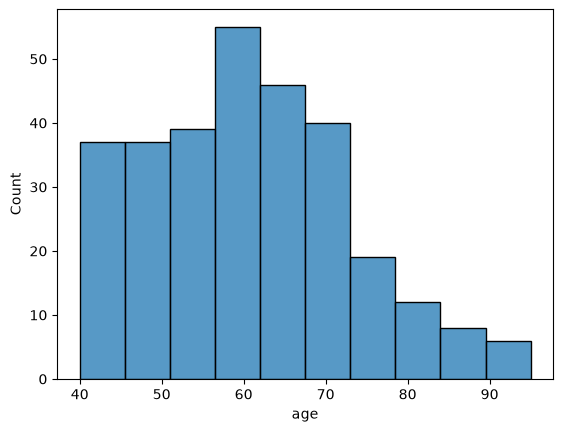

In [14]:
sns.histplot(x = 'age', data = df)

<Axes: xlabel='age', ylabel='Count'>

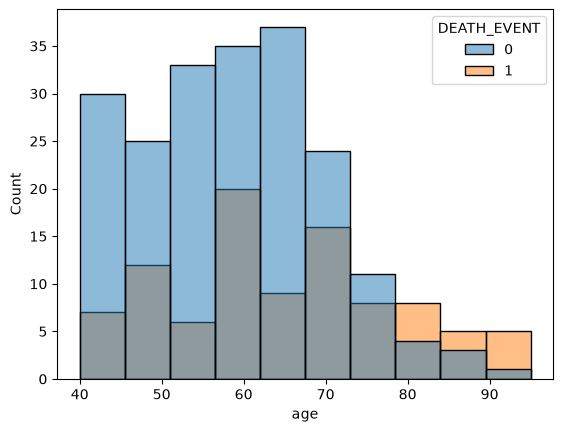

In [15]:
sns.histplot(x = 'age', data = df, hue='DEATH_EVENT')
# hue: 특정 열(범주형)의 값을 기준으로 데이터를 그룹화하여 서로 다른 색상으로 구분하여 표시

<Axes: xlabel='age', ylabel='Count'>

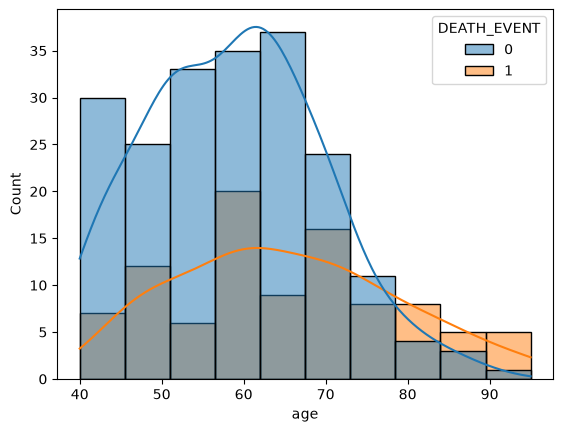

In [16]:
# kde : kernel density estimate (커널 밀도 추정) : 좀더 부드러운 곡선으로  (kde 플롯까지 같이 보여줌)
# 히스토그램 막대 위에 데이터의 분포를 부드러운 곡선 형태로 추정하여 덧그려주는 옵션

sns.histplot(x = 'age', data=df, hue='DEATH_EVENT', kde=True)

In [17]:
# age는 DEATH_EVENT를 가르는데 유용한가?
# age는 DEATH_EVENT를 가르는데 크게 유용하진 않다. (범위와 추세가 많이 겹쳐있다.)

### 크레아틴 키나제(creatinine_phosphokinase) 와 사망여부 (death event) 의 관계에 대한 분석

In [18]:
df.columns

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time',
       'DEATH_EVENT'],
      dtype='str')

<Axes: xlabel='creatinine_phosphokinase', ylabel='Count'>

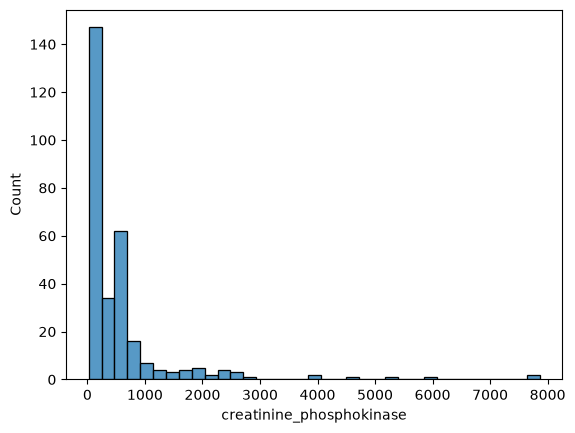

In [19]:
sns.histplot(x='creatinine_phosphokinase', data=df)

In [20]:
"""
아까 '기술통계량'에서 보았듯이 OUTLIER 가 굉장히 많습니다.
그래서 histogram 으로 유용한 데이터를 얻기가 현재로선 쉬워 보이진 않습니다.
"""
None

In [21]:
# outlier 를 배제하고 들여다 보면?
# 3000 이상을 배제해보자.

<Axes: xlabel='creatinine_phosphokinase', ylabel='Count'>

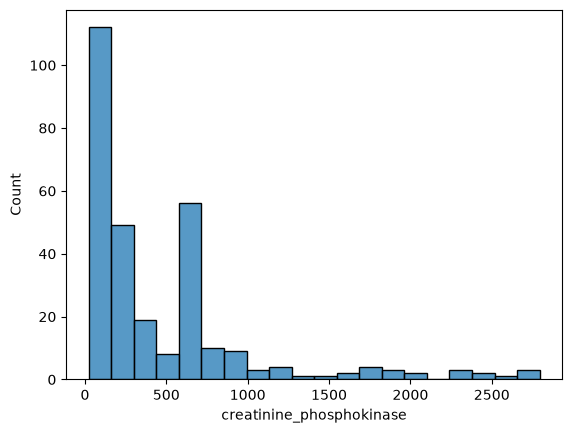

In [22]:
sns.histplot(x='creatinine_phosphokinase', 
             data=df.loc[df['creatinine_phosphokinase'] < 3000])

In [23]:
# 그럼에도 불구하고 '통계적인 특징'이 잘 들어나지 않는다.
# 이 정보는 유용하지 않을 가능성이 크다.

### 박출계수(ejection_fraction) 와 사망여부 (Death_Event) 의 관계에 대한 분석

In [24]:
df.columns

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time',
       'DEATH_EVENT'],
      dtype='str')

<Axes: xlabel='ejection_fraction', ylabel='Count'>

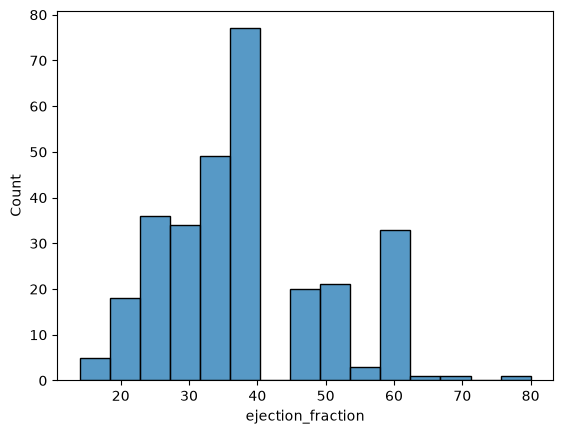

In [25]:
sns.histplot(x='ejection_fraction', data=df)

<Axes: xlabel='ejection_fraction', ylabel='Count'>

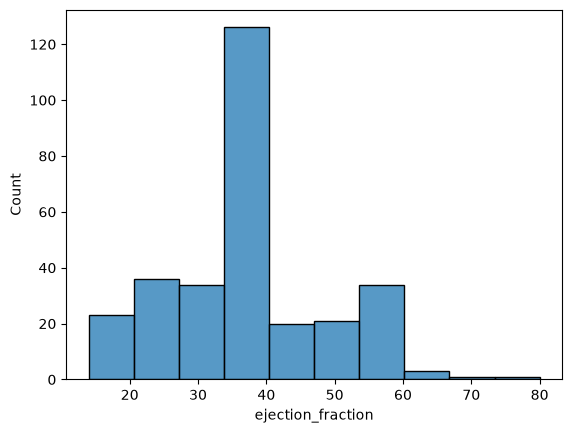

In [26]:
# 구간을 10개로 조정
sns.histplot(x='ejection_fraction', data=df, bins=10)

<Axes: xlabel='ejection_fraction', ylabel='Count'>

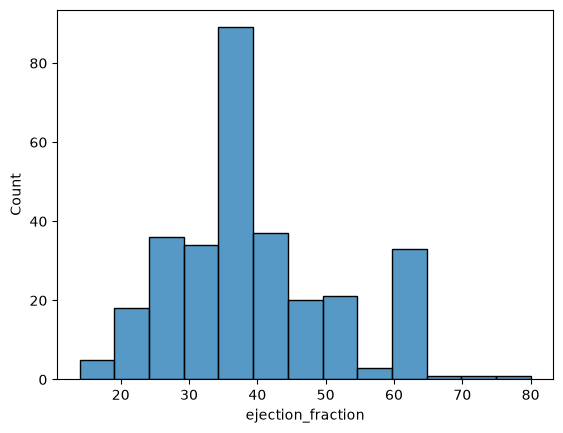

In [27]:
sns.histplot(x='ejection_fraction', data=df, bins=13)

In [28]:
# 어느정도 통계적으로 합리적인 데이터가 나온듯 하다.

<Axes: xlabel='ejection_fraction', ylabel='Count'>

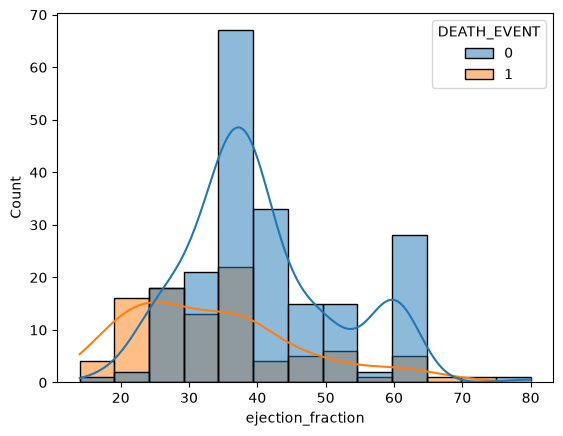

In [29]:
sns.histplot(x='ejection_fraction', data=df, bins=13, hue='DEATH_EVENT', kde=True)

In [30]:
"""
ejection_fraction 이 낮은 사람들이 사망을 많이 한것으로 확인할수 있습니다.
높으신 분들은  상대적으로 덜 사망하는것을 확인 가능

비율의 차이는 상당히 크긴 하지만, 
사망자 수 자체는 20 ~ 50 구간에 상당히 분포해 있다. (이미 심장병 환자들 중심으로 관측된 데이터.)

생존자를 걸러내는데는 상당히 도움이 될듯 하다.
"""
None


### 혈소판(platelets) 와 사망여부 (Death_Event) 의 관계에 대한 분석

In [31]:
df.columns

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time',
       'DEATH_EVENT'],
      dtype='str')

<Axes: xlabel='platelets', ylabel='Count'>

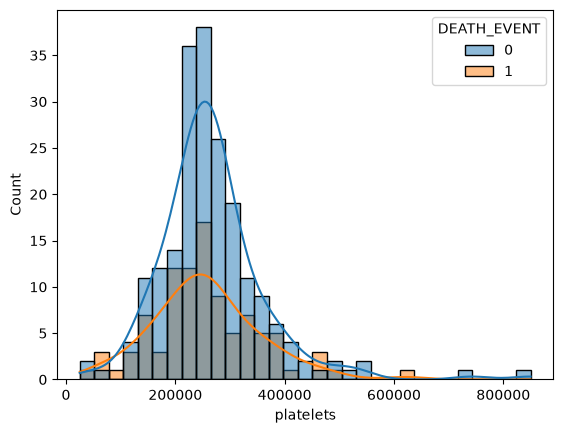

In [32]:
sns.histplot(x='platelets', data=df, hue='DEATH_EVENT', kde=True)

In [33]:
"""
혈소판 수치는 통계적으로 적절해 보이지만,

DEATH_EVENT 와는 거의 상관이 없어 보입니다. (혈소판 데이터는 분석에 굉장히 도움이 안될거 같다.)

"""
None

### '혈소판'과 'creatinine_phosphokinase' 그리고 '사망여부'와의 관계성 시각화하고 분석하기


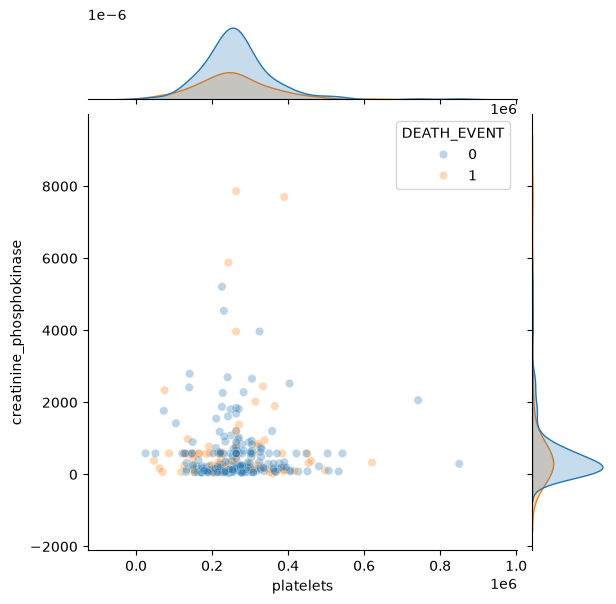

In [34]:
sns.jointplot(x='platelets', y='creatinine_phosphokinase',
              data=df, hue='DEATH_EVENT', alpha=0.3)

In [35]:
# scatter plot 의 뭉쳐있는 형태 -> 위 두개의 특징으로도 DEATH_EVENT 를 가르는데는
# 도움이 될거 같지 않다

## 범주형 데이터 분석

In [36]:
# seaborn의 Boxplot 계열(boxplot(), violinplot(), swarmplot())을 사용해본다
# Hint) hue 키워드를 사용하여 범주 세분화 가능


# 범주형 데이터의 경우
# 위 히스토그램 데이터를 볼수 있는 것과 달리
# boxplot 을 통해 범주별로 따로 통계를 내야 어느정도 확인을 할수 있다.

### 박출계수(ejection_fraction) 와 사망여부 (death event) 의 관계에 대한 분석

In [37]:
df.columns

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time',
       'DEATH_EVENT'],
      dtype='str')

<Axes: xlabel='DEATH_EVENT', ylabel='ejection_fraction'>

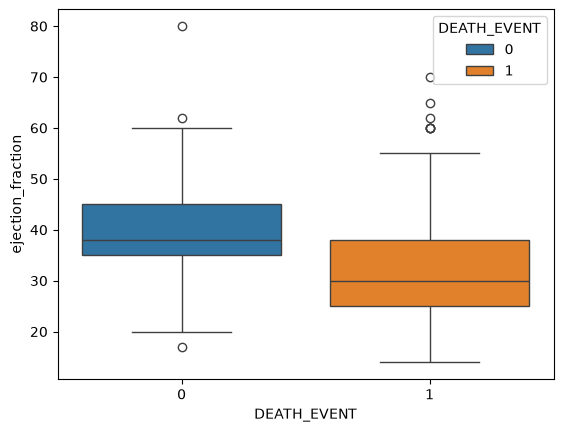

In [38]:
sns.boxplot(x='DEATH_EVENT', y='ejection_fraction', data=df, hue='DEATH_EVENT')

In [39]:
"""
생존(0) 한 사람과 사망(1)한 사람 사이에 
ejection_fraction의  평균과 전체적인 값의 범위에 차이가 어느정도 있슴을 확인
ejection_fraction 은 DEATH_EVENT 에 영향을 주는거 같다
"""
None

In [40]:
# DEATH_EVENT !  생존(0)이냐? 사망(1)이냐? 에 따른 ejection_fration 을 boxplot 을 본겁니다.

# - 일단 평균에서 어느정도 차이가 난다 
# - 전체적인 값의 범위의 차이도 확인 가능

# boxplot 의 최대 장점은 outlier 를 바깥으로 빼줍니다.  두개(범주)의 통계수치를 간단하게 비교할수 있다는 점입니다.

# 히스토그램으로 보았을때는 위의 ↓ 과 비슷한 급의 정보다.
#     sns.histplot(x='ejection_fraction', data=df, bins=13, hue="DEATH_EVENT", kde=True) 
# 히스토그램은 '겹쳐져' 보이기 때문에 많은 정보를 '한번에' 파악하기 어려웠다면
# boxplot 을 이용할때는 일목요연하게 비교를 할수가 있다. 

# boxplot은 '경영층' 에서 많이 사용하는 통계수치 입니다.  
# 여러분이 경영층과 이야기 할때는 이와 같은 boxplot 을 이용해서 프레젠테이션 하면, 경영층에서
# 더 쉽게 받아들일수 있는 중요한 그래프라고 볼수 있습니다.

### 흡연여부(smoking) 와 사망여부 (death event) 의 관계에 대한 분석

In [41]:
df['smoking'].value_counts

<bound method IndexOpsMixin.value_counts of 0      0
1      0
2      1
3      0
4      0
      ..
294    1
295    0
296    0
297    1
298    1
Name: smoking, Length: 299, dtype: int64>

<Axes: xlabel='smoking', ylabel='ejection_fraction'>

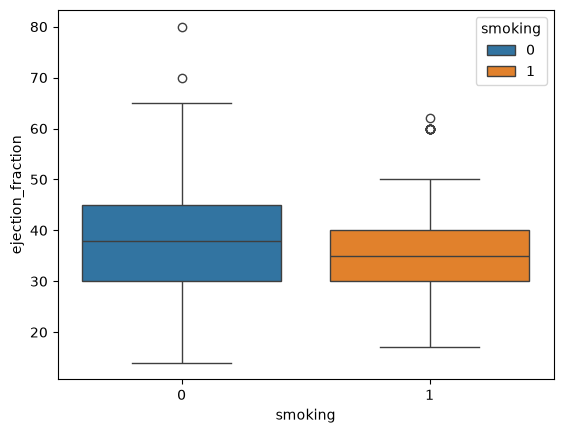

In [42]:
# 우선 흡연여부와 심박출계수 관계 확인
sns.boxplot(x='smoking', y='ejection_fraction', data=df, hue='smoking')

<Axes: xlabel='smoking', ylabel='ejection_fraction'>

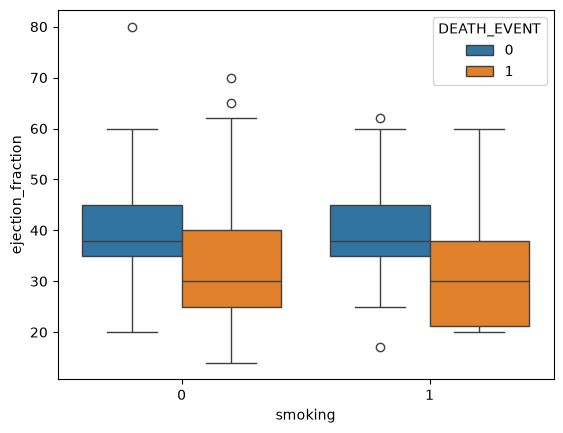

In [43]:
sns.boxplot(x='smoking', y='ejection_fraction', data=df, hue='DEATH_EVENT')

<Axes: xlabel='DEATH_EVENT', ylabel='ejection_fraction'>

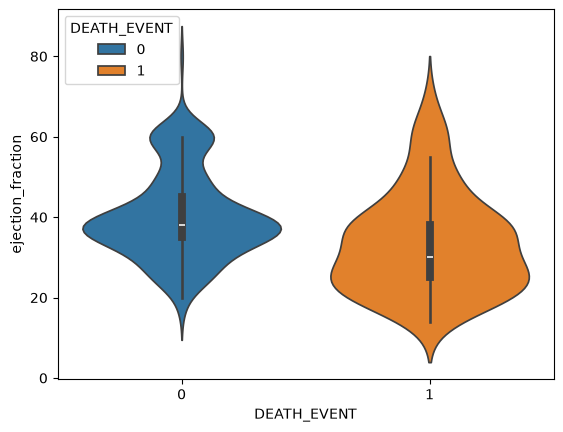

In [44]:
sns.violinplot(x='DEATH_EVENT', y='ejection_fraction', data=df, hue='DEATH_EVENT')

<Axes: xlabel='DEATH_EVENT', ylabel='ejection_fraction'>

/opt/miniconda3/envs/KDT-py/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


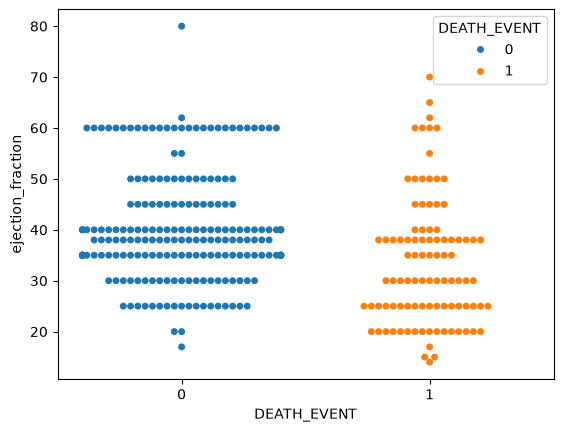

In [45]:
sns.swarmplot(x='DEATH_EVENT', y='ejection_fraction', data=df, hue='DEATH_EVENT')

<Axes: xlabel='DEATH_EVENT', ylabel='ejection_fraction'>

/opt/miniconda3/envs/KDT-py/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


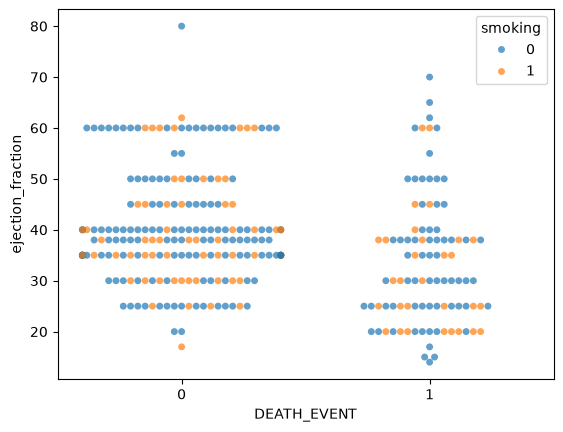

In [46]:
sns.swarmplot(x='DEATH_EVENT', y='ejection_fraction', data=df, hue='smoking', alpha=0.7)

### countplot 을 사용하여 범주형 통계 확인

<Axes: xlabel='DEATH_EVENT', ylabel='count'>

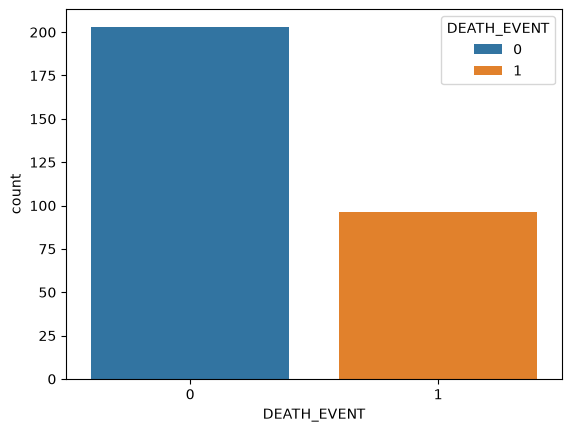

In [47]:
sns.countplot(x='DEATH_EVENT', data=df, hue='DEATH_EVENT')

<Axes: xlabel='sex', ylabel='count'>

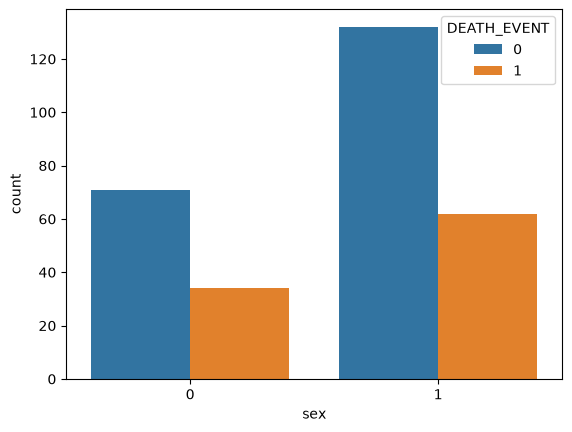

In [48]:
sns.countplot(x='sex', data=df, hue='DEATH_EVENT')

# Step3 모델학습을 위한 데이터 전처리

## 분류형, 수치형 구분하기

In [49]:
df.columns

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time',
       'DEATH_EVENT'],
      dtype='str')

In [50]:
X_num = df[['age', 'creatinine_phosphokinase','ejection_fraction', 'platelets','serum_creatinine', 'serum_sodium']]
X_cat = df[['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']]
y = df['DEATH_EVENT']

In [51]:
X_num.head()

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium
0,75.0,582,20,265000.00,1.9,130
1,55.0,7861,38,263358.03,1.1,136
2,65.0,146,20,162000.00,1.3,129
3,50.0,111,20,210000.00,1.9,137
4,65.0,160,20,327000.00,2.7,116


In [52]:
X_cat.head()

,anaemia,diabetes,high_blood_pressure,sex,smoking
0,0,0,1,1,0
1,0,0,0,1,0
2,0,0,0,1,1
3,1,0,0,1,0
4,1,1,0,0,0


## StandardScaler를 사용하여 스케일링

In [53]:
from sklearn.preprocessing import StandardScaler

In [54]:
# 범주형 데이터는 이미 0, 1 one-hot encoding 되어 있는 상태.

# 수치형 데이터만 스케일링 한다.

In [55]:
scaler = StandardScaler()
scaler.fit(X_num)
X_scaled = scaler.transform(X_num)

X_scaled = pd.DataFrame(data=X_scaled, index=X_num.index, columns=X_num.columns)
X_scaled.head()

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium
0,1.192945,0.000166,-1.530560,1.681648e-02,0.490057,-1.504036
1,-0.491279,7.514640,-0.007077,7.535660e-09,-0.284552,-0.141976
2,0.350833,-0.449939,-1.530560,-1.038073e+00,-0.090900,-1.731046
3,-0.912335,-0.486071,-1.530560,-5.464741e-01,0.490057,0.085034
4,0.350833,-0.435486,-1.530560,6.517986e-01,1.264666,-4.682176


In [56]:
X_scaled.describe()

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium
count,2.990000e+02,299.000000,2.990000e+02,2.990000e+02,2.990000e+02,2.990000e+02
mean,5.703353e-16,0.000000,-3.267546e-17,7.723291e-17,1.425838e-16,-8.673849e-16
std,1.001676e+00,1.001676,1.001676e+00,1.001676e+00,1.001676e+00,1.001676e+00
min,-1.754448e+00,-0.576918,-2.038387e+00,-2.440155e+00,-8.655094e-01,-5.363206e+00
25%,-8.281242e-01,-0.480393,-6.841802e-01,-5.208700e-01,-4.782047e-01,-5.959961e-01
50%,-7.022315e-02,-0.342574,-7.076750e-03,-1.390846e-02,-2.845524e-01,8.503384e-02
75%,7.718891e-01,0.000166,5.853888e-01,4.111199e-01,5.926150e-03,7.660638e-01
max,2.877170e+00,7.514640,3.547716e+00,6.008180e+00,7.752020e+00,2.582144e+00


In [57]:
X = pd.concat([X_scaled, X_cat], axis=1)
X.head()

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,anaemia,diabetes,high_blood_pressure,sex,smoking
0,1.192945,0.000166,-1.530560,1.681648e-02,0.490057,-1.504036,0,0,1,1,0
1,-0.491279,7.514640,-0.007077,7.535660e-09,-0.284552,-0.141976,0,0,0,1,0
2,0.350833,-0.449939,-1.530560,-1.038073e+00,-0.090900,-1.731046,0,0,0,1,1
3,-0.912335,-0.486071,-1.530560,-5.464741e-01,0.490057,0.085034,1,0,0,1,0
4,0.350833,-0.435486,-1.530560,6.517986e-01,1.264666,-4.682176,1,1,0,0,0


## 학습용 / 테스트용 데이터 분리

In [58]:
from sklearn.model_selection import train_test_split

In [59]:
X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.3, random_state=42)

X_train.shape, X_test.shape

((209, 11), (90, 11))

# Step4. 모델 학습하기

## 모델 생성 및 학습

In [60]:
from sklearn.linear_model import LogisticRegression

In [61]:
model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

## 학습결과 평가

In [62]:
# 분류형 모델의 경우
# precision, recall, f1-score 등을 가장 손쉽게 보는 방법
# classification_report 사용

In [63]:
from sklearn.metrics import classification_report

In [64]:
pred = model_lr.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.67      0.91      0.77        53
           1       0.72      0.35      0.47        37

    accuracy                           0.68        90
   macro avg       0.69      0.63      0.62        90
weighted avg       0.69      0.68      0.65        90



## XGBoost 모델 생성/학습

In [65]:
from xgboost import XGBClassifier

In [68]:
model_xgb = XGBClassifier()
model_xgb.fit(X_train, y_train);

## 학습결과 평가

In [69]:
pred = model_xgb.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.68      0.81      0.74        53
           1       0.63      0.46      0.53        37

    accuracy                           0.67        90
   macro avg       0.66      0.64      0.64        90
weighted avg       0.66      0.67      0.65        90



## 특성중요도

In [70]:
model_xgb.feature_importances_

array([0.11330909, 0.07535392, 0.12970458, 0.05928127, 0.2165242 ,
       0.06204965, 0.03370712, 0.06648672, 0.06410143, 0.12330787,
       0.05617411], dtype=float32)

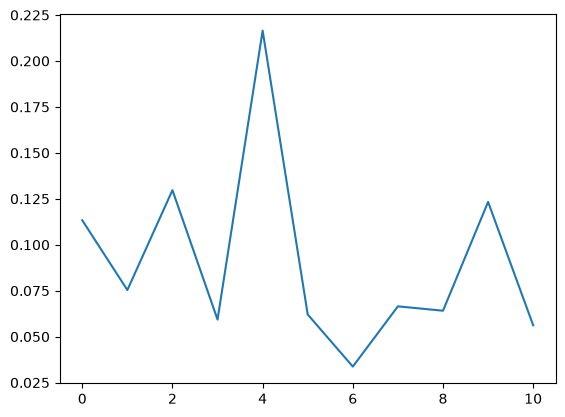

In [71]:
plt.plot(model_xgb.feature_importances_)
plt.show()

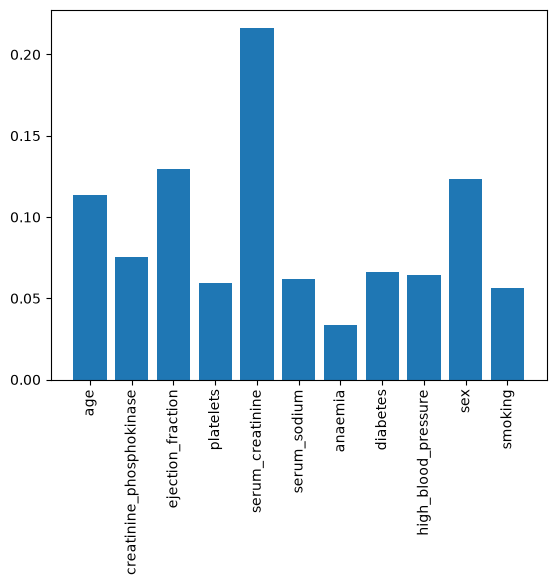

In [72]:
plt.bar(X.columns, model_xgb.feature_importances_)
plt.xticks(rotation=90)
plt.show()

In [73]:
df.columns

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time',
       'DEATH_EVENT'],
      dtype='str')

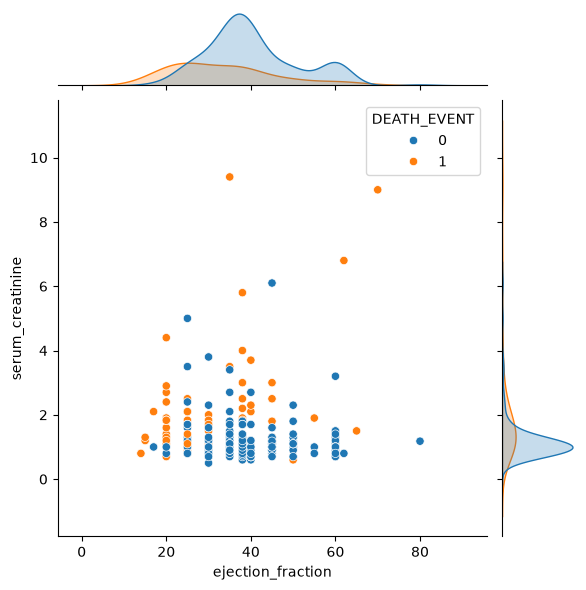

In [74]:
sns.jointplot(x='ejection_fraction', y='serum_creatinine', data=df, hue='DEATH_EVENT')

# 모델 학습결과 심화분석

## Roc curve

In [75]:
from sklearn.metrics import roc_curve

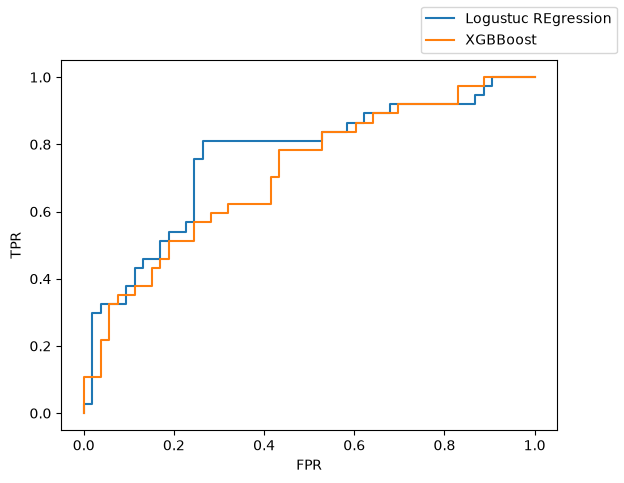

In [79]:
fig = plt.figure()
ax = fig.gca()  # gca(): get current axes

proba_lr = model_lr.predict_proba(X_test)[:, 1]
proba_xgb = model_xgb.predict_proba(X_test)[:, 1]

fprs, tprs, thresholds = roc_curve(y_test, proba_lr)
ax.plot(fprs, tprs, label='Logustuc REgression')

fprs, tprs, thresholds = roc_curve(y_test, proba_xgb)
ax.plot(fprs, tprs, label='XGBBoost')

ax.set_xlabel('FPR')
ax.set_ylabel('TPR')

fig.legend()

plt.show()

In [80]:
from sklearn.metrics import RocCurveDisplay

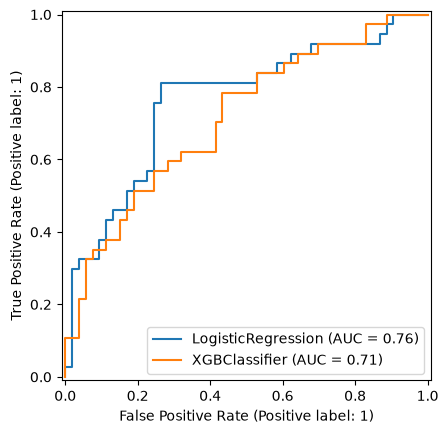

In [81]:
fig = plt.figure()
ax = fig.gca()

RocCurveDisplay.from_estimator(model_lr, X_test, y_test, ax=ax)
RocCurveDisplay.from_estimator(model_xgb, X_test, y_test, ax=ax)

plt.show()

## Precision_Recall 커브

In [ ]:
# Precision-Recall 커브는 Precision 과 Recall 의 관계를 보는 겁니다.
#  ex) Recall 을 유지하면서 Precision 을 얼마나 끌어올릴수 있는지..

In [83]:
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay

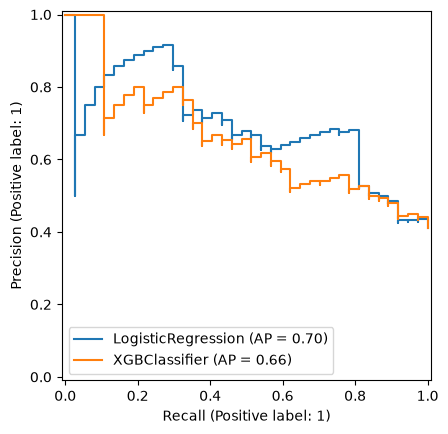

In [86]:
fig = plt.figure()
ax = fig.gca()

PrecisionRecallDisplay.from_estimator(model_lr, X_test, y_test, ax=ax)
PrecisionRecallDisplay.from_estimator(model_xgb, X_test, y_test, ax=ax)

plt.show()

In [ ]:
# Presision 이 1부터 시작하여 (좌상단) Recall 을 증가시킬때 (우측방향)  어떻게 요동치는지를 볼수가 있다.
# 재미있는 그림이 나옵니다. 
# Precision 은 AP 라는 값이 높을수록 Recall 을 증가시키면서 잘 유지 되었다는 뜻. AP 값은 1에 가까울수록 더 좋다고 볼수 있다.